In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/hdb_resale.csv")

print(df.shape)
print(df.dtypes)
df.head()

(238815, 11)
month                      str
town                       str
flat_type                  str
block                      str
street_name                str
storey_range               str
floor_area_sqm         float64
flat_model                 str
lease_commence_date      int64
remaining_lease            str
resale_price           float64
dtype: object


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [2]:
#extract year and month from transaction date
df["year"] = df["month"].str[:4].astype(int)
df["month_num"] = df["month"].str[5:].astype(int)

#extract storey midpoint from range e.g. "10 TO 12" -> 11
df["storey_mid"] = df["storey_range"].str.extract(r'(\d+)\s+TO\s+(\d+)').astype(float).mean(axis=1)

#extract remaining lease in years as decimal
def parse_lease(s):
    if pd.isna(s):
        return np.nan
    years = 0
    months = 0
    y = pd.Series(s).str.extract(r'(\d+)\s+year')
    m = pd.Series(s).str.extract(r'(\d+)\s+month')
    if not y[0].isna().all():
        years = float(y[0].iloc[0])
    if not m[0].isna().all():
        months = float(m[0].iloc[0])
    return years + months / 12

df["lease_remaining"] = df["remaining_lease"].apply(parse_lease)

#flat type to ordered numeric
flat_type_order = {
    "1 ROOM": 1, "2 ROOM": 2, "3 ROOM": 3,
    "4 ROOM": 4, "5 ROOM": 5, "EXECUTIVE": 6, "MULTI-GENERATION": 7
}
df["flat_type_num"] = df["flat_type"].map(flat_type_order)

#check results
print(df[["storey_range", "storey_mid", "remaining_lease", "lease_remaining", "flat_type", "flat_type_num"]].head(10))
print(f"\nMissing values:\n{df[['storey_mid', 'lease_remaining', 'flat_type_num']].isna().sum()}")

  storey_range  storey_mid     remaining_lease  lease_remaining flat_type  \
0     10 TO 12        11.0  61 years 04 months        61.333333    2 ROOM   
1     01 TO 03         2.0  60 years 07 months        60.583333    3 ROOM   
2     01 TO 03         2.0  62 years 05 months        62.416667    3 ROOM   
3     04 TO 06         5.0   62 years 01 month        62.083333    3 ROOM   
4     01 TO 03         2.0  62 years 05 months        62.416667    3 ROOM   
5     01 TO 03         2.0            63 years        63.000000    3 ROOM   
6     04 TO 06         5.0  61 years 06 months        61.500000    3 ROOM   
7     04 TO 06         5.0  58 years 04 months        58.333333    3 ROOM   
8     04 TO 06         5.0  61 years 06 months        61.500000    3 ROOM   
9     01 TO 03         2.0  61 years 04 months        61.333333    3 ROOM   

   flat_type_num  
0              2  
1              3  
2              3  
3              3  
4              3  
5              3  
6              3  


       resale_price  floor_area_sqm  storey_mid  lease_remaining
count     238815.00       238815.00   238815.00        238815.00
mean      533994.32           96.68        8.79            74.10
std       191780.11           24.01        5.96            14.32
min       140000.00           31.00        2.00            39.33
25%       390000.00           81.00        5.00            62.17
50%       500888.00           93.00        8.00            73.83
75%       640000.00          112.00       11.00            88.58
max      1728000.00          366.70       50.00            97.75


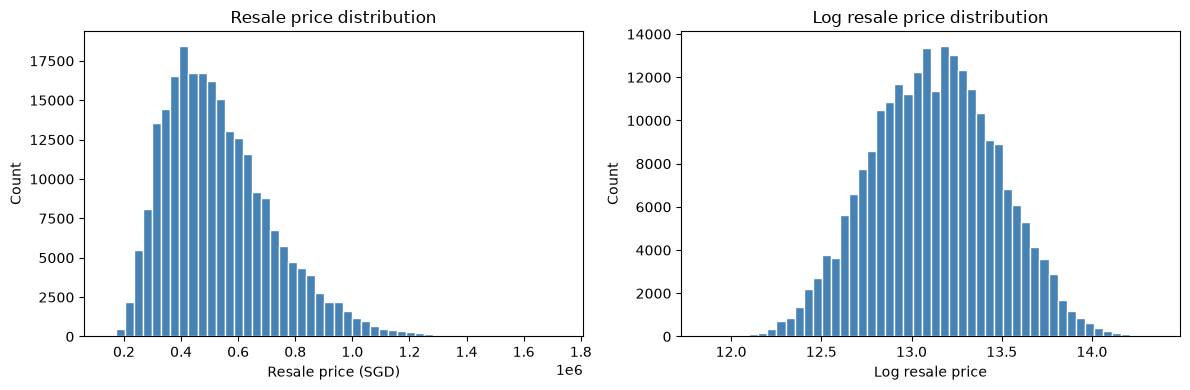

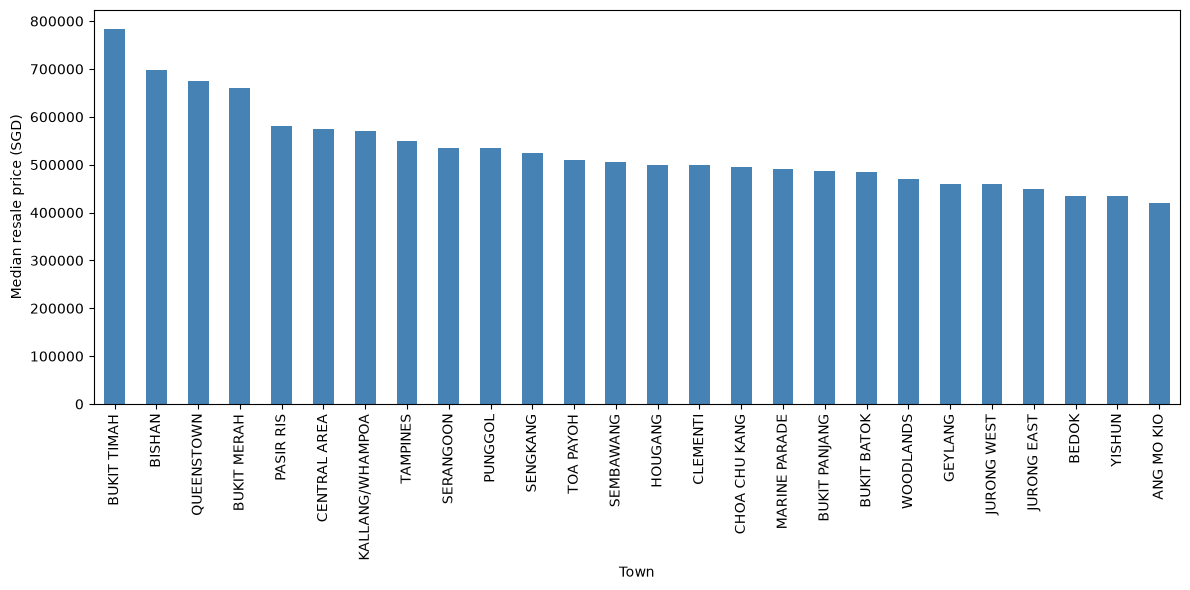

In [3]:
#summary stats for key variables
print(df[["resale_price", "floor_area_sqm", "storey_mid", "lease_remaining"]].describe().round(2))

#price distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["resale_price"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Resale price (SGD)")
axes[0].set_ylabel("Count")
axes[0].set_title("Resale price distribution")

axes[1].hist(np.log(df["resale_price"]), bins=50, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Log resale price")
axes[1].set_ylabel("Count")
axes[1].set_title("Log resale price distribution")

plt.tight_layout()
plt.show()

#median price by town
town_price = df.groupby("town")["resale_price"].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
town_price.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Town")
ax.set_ylabel("Median resale price (SGD)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

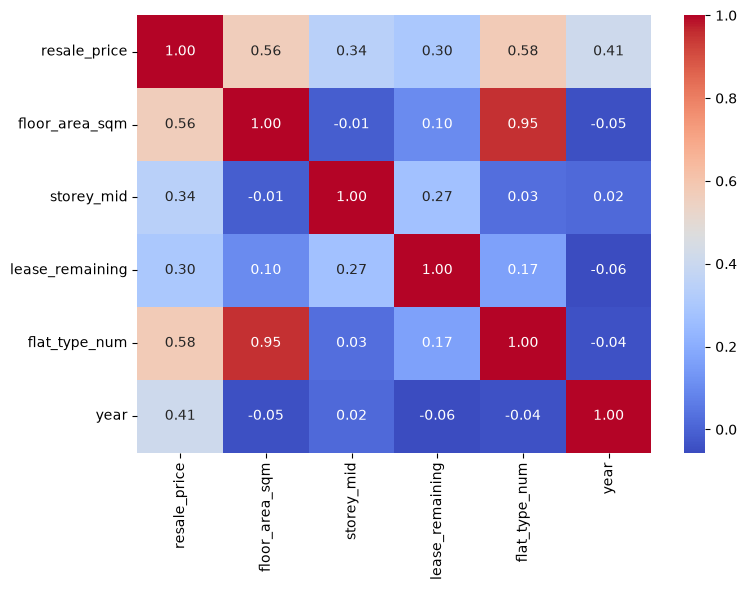

Correlations with resale price:
resale_price       1.000
flat_type_num      0.575
floor_area_sqm     0.564
year               0.412
storey_mid         0.342
lease_remaining    0.301
Name: resale_price, dtype: float64


In [4]:
#correlation between numeric features and resale price
numeric_cols = ["resale_price", "floor_area_sqm", "storey_mid", "lease_remaining", "flat_type_num", "year"]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
plt.tight_layout()
plt.show()

#print correlations with resale price specifically
print("Correlations with resale price:")
print(corr["resale_price"].sort_values(ascending=False).round(3))

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

#encode town as dummy variables
df_model = pd.get_dummies(df, columns=["town"], drop_first=True)

#features
feature_cols = (
    ["floor_area_sqm", "storey_mid", "lease_remaining", "flat_type_num", "year"]
    + [c for c in df_model.columns if c.startswith("town_")]
)

X = df_model[feature_cols]
y = np.log(df_model["resale_price"])

#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

#evaluate on original scale
price_pred_lr = np.exp(y_pred_lr)
price_test = np.exp(y_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(price_test, price_pred_lr)

print(f"Linear Regression (log scale):")
print(f"  R² = {r2_lr:.4f}")
print(f"  MAE = S${mae_lr:,.0f}")

#gradient boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

price_pred_gb = np.exp(y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(price_test, price_pred_gb)

print(f"\nGradient Boosting (log scale):")
print(f"  R² = {r2_gb:.4f}")
print(f"  MAE = S${mae_gb:,.0f}")

Linear Regression (log scale):
  R² = 0.8861
  MAE = S$48,354

Gradient Boosting (log scale):
  R² = 0.9330
  MAE = S$37,203
